In [26]:
#import libraries
import requests
import matplotlib.pyplot as plt
import seaborn as sb
import pandas as pd


#establishes base url for KGLW API
base_url = "https://kglw.net/api/v2/setlists/showyear/"

#creates list of years
years = [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

#creates empty dictionary to store setlists by year
setlists_by_year = {}

#iterates through each year in list of years
for year in years:
    #creates unique url with base url and year
    url = "{}{}.json".format(base_url, year)
    #sends a get request to url for response in JSON format
    response = requests.get(url).json()
    #stores the setlist data for current year in dictionary
    setlists_by_year[year] = response["data"]
    #prints the year and number of setlists
    print("{}: {} setlists".format(year, len(setlists_by_year[year])))

2010: 14 setlists
2011: 64 setlists
2012: 51 setlists
2013: 137 setlists
2014: 398 setlists
2015: 489 setlists
2016: 796 setlists
2017: 1311 setlists
2018: 1350 setlists
2019: 989 setlists
2020: 99 setlists
2021: 253 setlists
2022: 1021 setlists
2023: 793 setlists
2024: 1048 setlists


Year: 2010, Number of Shows: 14
Year: 2011, Number of Shows: 64
Year: 2012, Number of Shows: 51
Year: 2013, Number of Shows: 137
Year: 2014, Number of Shows: 398
Year: 2015, Number of Shows: 489
Year: 2016, Number of Shows: 796
Year: 2017, Number of Shows: 1311
Year: 2018, Number of Shows: 1350
Year: 2019, Number of Shows: 989
Year: 2020, Number of Shows: 99
Year: 2021, Number of Shows: 253
Year: 2022, Number of Shows: 1021
Year: 2023, Number of Shows: 793
Year: 2024, Number of Shows: 1048


C:\Users\agysi\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


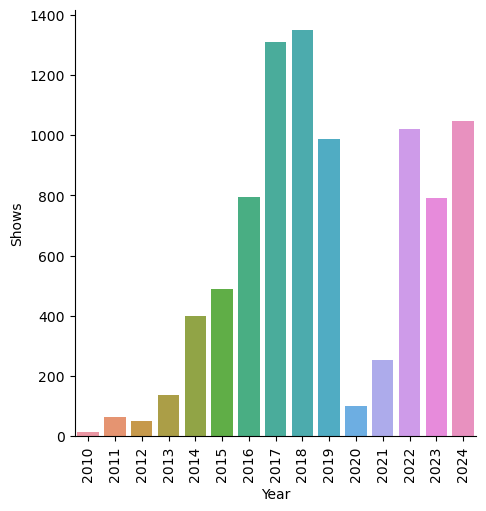

In [27]:
#initializes a dictionary to store year and show counts
shows_by_year = {'Year': [], 'Shows': []}
#iterates through indices of years list
for i in range(len(years)):
    #gets year for current index
    year = years[i]
    #get setlist for current year
    setlists = setlists_by_year.get(year)
    #show count is equal to lenth of setlists
    show_count = len(setlists)
    #append the year to 'Year' list in dictionary
    shows_by_year['Year'].append(year)
    #append show count to 'Shows' list in dictionary
    shows_by_year['Shows'].append(show_count)
    #print year and number of shows
    print("Year: {}, Number of Shows: {}".format(year, show_count))

#loads data into pandas dataframe
df = pd.DataFrame(shows_by_year)

#plots data
sb.catplot(x="Year", y="Shows", data=df, kind="bar").set_xticklabels(rotation=90)


Top Songs Across Entire Career:
                songname  count
0             Robot Stop    304
1             Cellophane    291
2            Gamma Knife    270
3              The River    219
4            Rattlesnake    210
5       I'm In Your Mind    208
6   I'm Not In Your Mind    204
7        People-Vultures    196
8  The Lord of Lightning    190
9  I'm In Your Mind Fuzz    172


C:\Users\agysi\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


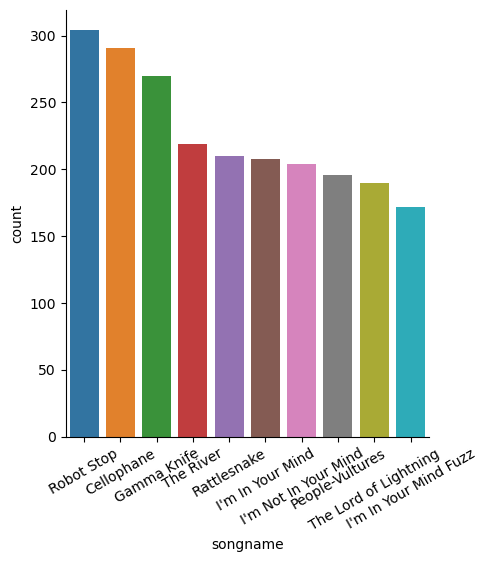

In [28]:
def count_and_plot_songs():
    #creates empty list to store all song data
    all_songs_list = []

    #counts songs for each year and stores song counts
    for year in setlists_by_year:
        
        #gets the setlists for the current year
        setlists = setlists_by_year[year]  

        #loops through each song in the setlist for that year
        for song in setlists:
            #gets the song name
            songname = song.get("songname")
            #adds song data (year and song name) to the list
            all_songs_list.append({"year": year, "songname": songname})  

    #creates a DataFrame for all the song counts (for all years)
    all_songs_data = pd.DataFrame(all_songs_list)

    #groups data by song name, counts the number of times each song is played
    overall_songs_df = (
        all_songs_data.groupby("songname")  # groups by songname
        .agg({"year": "count"})  # counts how many times each song appears
    )

    #renames the column in the DataFrame to "count"
    overall_songs_df.columns = ['count']  

    #sorts the songs by count in descending order
    overall_songs_df = overall_songs_df.sort_values("count", ascending=False) 

    #print statement
    print("Top Songs Across Entire Career:")

    #selects the top 10 most played songs and resets the index
    top_10_songs = overall_songs_df.iloc[:10].reset_index()
    #prints the top 10 songs
    print(top_10_songs)

    #plots the top 10 songs as a bar plot using Seaborn
    sb.catplot(x="songname", y="count", data=top_10_songs, kind="bar").set_xticklabels(rotation=30)
    

#calls the function
count_and_plot_songs()



Year: 2010, Average Setlist Length: 7
Year: 2011, Average Setlist Length: 4
Year: 2012, Average Setlist Length: 3
Year: 2013, Average Setlist Length: 5
Year: 2014, Average Setlist Length: 5
Year: 2015, Average Setlist Length: 8
Year: 2016, Average Setlist Length: 11
Year: 2017, Average Setlist Length: 15
Year: 2018, Average Setlist Length: 17
Year: 2019, Average Setlist Length: 17
Year: 2020, Average Setlist Length: 12
Year: 2021, Average Setlist Length: 15
Year: 2022, Average Setlist Length: 14
Year: 2023, Average Setlist Length: 13
Year: 2024, Average Setlist Length: 16


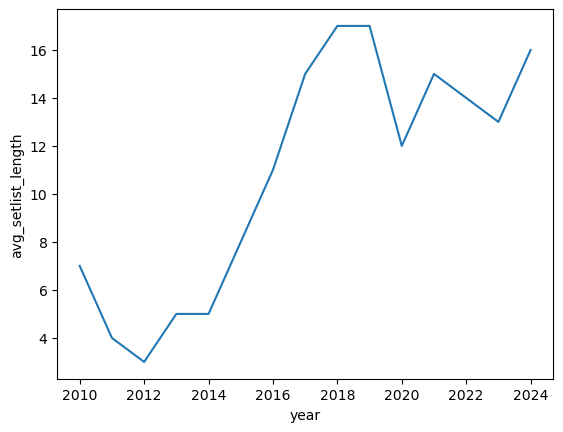

In [29]:
#import libraries
import seaborn as sb
import pandas as pd  # for DataFrame creation and manipulation

def calculate_and_plot_avg_setlist_length():
    #creates empty list to store year and average setlist length data
    all_setlist_data = []  
    
    #iterates through each year in setlists_by_year
    for year in setlists_by_year:
        #gets setlist for current year and stores in setlists
        setlists = setlists_by_year[year]  

        #creates empty list to store show ids for current year
        show_ids = []  

        #iterates through each setlist in setlists
        for setlist in setlists:
            #gets show id from setlist
            show_id = setlist.get("show_id")
            #appends show_id to show_ids list
            show_ids.append(show_id)  

        #creates empty dictionary to store counts of show_ids
        show_counts = {}  
        
        #iterates through each show_id in show_ids
        for show_id in show_ids:
            #increases count for current show id
            show_counts[show_id] = show_counts.get(show_id, 0) + 1
            
        #stores total shows as length of show_counts
        total_shows = len(show_counts)  
        #stores total setlists as length of show_ids
        total_setlists = len(show_ids)  
        
        #calculates average length using floor division
        avg_length = total_setlists // total_shows  
        
        #adds current year and avg_length to the all_setlist_data list
        all_setlist_data.append({"year": year, "avg_setlist_length": avg_length})  
        
        #print the year and calculated average setlist length
        print("Year: {}, Average Setlist Length: {}".format(year, avg_length))
    
    #creates DataFrame for setlist data
    df = pd.DataFrame(all_setlist_data)  
    
    #plots data
    sb.lineplot(data=df, x="year", y="avg_setlist_length")  
    

#calls the function
calculate_and_plot_avg_setlist_length()


In [30]:
import requests
from bs4 import BeautifulSoup

def fetch_lastfm_top_tracks():
    #defines url
    url = "https://www.last.fm/music/King+Gizzard+&+The+Lizard+Wizard/+tracks"
    #sends get request to url and stores response
    response = requests.get(url)
    #creates object to parse HTML content
    soup = BeautifulSoup(response.text, 'html.parser')
    
    #finds all td elements with class 'chartlist'
    track_elements = soup.find_all('td', {'class': 'chartlist-name'})
    #initializes an empty list
    track_names = []
    #iterates through each track_element in track_elements
    for track_element in track_elements:
        #find a tags within track element
        a_tag = track_element.find('a')
        #if a_tag is found
        if a_tag:
            #appends text of a tag to the track names list
            track_names.append(a_tag.text.strip())
    
    #print statement
    print("Top 10 Listened to KGLW Tracks from Last.fm")
    #iterates through the first all track names
    for i in range(len(track_names)):
            #if i is less than 10
            if i < 10:
                #print track ranking and name
                print("{}. {}".format(i + 1, track_names[i]))
            
#call the function
fetch_lastfm_top_tracks()

Top 10 Listened to KGLW Tracks from Last.fm
1. Work This Time
2. Sense
3. Slow Jam 1
4. Robot Stop
5. Kepler-22b
6. Rattlesnake
7. Gamma Knife
8. Shanghai
9. Magenta Mountain
10. People-Vultures


In [31]:
#import library
import requests

#My unique api key
DISCOGS_API_KEY = #replace with your key

def get_artist_info(artist_id):
   
    #creates URL for API request including unique artist_id
    url = "https://api.discogs.com/artists/{}".format(artist_id)

    #defines unique headers with unique key for authorization into Discogs API
    headers = {
        "Authorization": "Discogs token={}".format(DISCOGS_API_KEY)
    }

    #sends GET request to URL with specified headers for authorization
    response = requests.get(url, headers=headers)

    #converts response to JSON
    artist_data = response.json()

    #checks if name key exists in artist_data dictionary
    if "name" in artist_data:
        # Prints artist name
        print("Artist Name: {}".format(artist_data["name"]))

    #checks if profile key exists in artist_data dictionary
    if "profile" in artist_data:
        #prints profile
        print("Profile: {}".format(artist_data["profile"]))

    #checks if 'members' key exists
    if artist_data.get("members"):
        #print statement
        print("Band Members:")
        #iterates through each member
        for member in artist_data["members"]:
            #prints members name with name key
            print("- {}".format(member.get("name")))

    #checks if urls key exists and has something
    if "urls" in artist_data and artist_data["urls"]:
        #Print statement
        print("Links:")
        #iterates through each link in urls
        for link in artist_data["urls"]:
            #prints each link
            print("- {}".format(link))


#unique artist id for King Gizzard
artist_id = 2532180
#calls the function
get_artist_info(artist_id)

Artist Name: King Gizzard And The Lizard Wizard
Profile: Psychedelic rock band from Melbourne, Victoria. Australia.
Formed 2010.
Band Members:
- Ambrose Kenny-Smith
- Eric Moore (6)
- Stu Mackenzie
- Joe Walker (8)
- Lucas Skinner
- Cook Craig
- Michael Cavanagh (2)
Links:
- Website - http://kinggizzardandthelizardwizard.com/
- Facebook - https://www.facebook.com/kinggizzardandthelizardwizard
- Soundcloud - https://soundcloud.com/king-gizzard-the-lizard-wizard
- Wiki - https://en.wikipedia.org/wiki/King_Gizzard_%26_the_Lizard_Wizard 
- Instagram - https://www.instagram.com/kinggizzard 
- Bandcamp - https://kinggizzard.bandcamp.com 
- Twitter - https://twitter.com/kinggizzard 
- https://www.youtube.com/@KingGizzardAndTheLizardWizard


In [32]:
#import libraries
import requests  # for sending HTTP requests to the YouTube API
import pandas as pd  # for creating and manipulating tabular data

#my unique api key
YOUTUBE_API_KEY =  # replace with your YouTube API key
#king gizzards channel id
channel_id = "UCNiyS8zr2RIddszLwtoyUow"  # King Gizzard's YouTube channel ID


#formats url to include channel id and youtube api key
channel_url = "https://www.googleapis.com/youtube/v3/channels?part=contentDetails&id={}&key={}".format(channel_id, YOUTUBE_API_KEY)

#sends get request to url as JSON
channel_response = requests.get(channel_url).json()

#checks if "items" is in channel response and if it's not empty
if "items" in channel_response and len(channel_response["items"]) > 0:
    #extracts the id of the channel's uploads playlist from the response
    uploads_playlist_id = channel_response["items"][0]["contentDetails"]["relatedPlaylists"]["uploads"]
    #print statement
    print("Uploads Playlist ID: {}".format(uploads_playlist_id))
else:
    #error message if no playlist id is found
    print("Failed to get uploads")
    
    

#checks if uploads_playlist_id is valid
if uploads_playlist_id:
    #loading statement; it takes a few seconds
    print("Getting data, please be patient...")

    #video url with playlist id and api key
    video_url = "https://www.googleapis.com/youtube/v3/playlistItems?part=snippet,contentDetails&playlistId={}&maxResults=50&key={}".format(uploads_playlist_id, YOUTUBE_API_KEY)
    
    #sends get request to video url as JSON
    video_response = requests.get(video_url).json()

    #creates empty list
    video_data = []

    #checks if "items" is in video response
    if "items" in video_response:
        #iterates through each video item in the response
        for video in video_response["items"]:
            #extracts the video id
            video_id = video["contentDetails"]["videoId"]
            #extracts the video title
            video_title = video["snippet"]["title"]

            #creates url to get stats with video id and api key
            stats_url = "https://www.googleapis.com/youtube/v3/videos?part=statistics&id={}&key={}".format(video_id, YOUTUBE_API_KEY)
            
            #sends a get request to stats url for JSON
            stats_response = requests.get(stats_url).json()

            #default view count to 0
            view_count = 0
            
            #checks if "items" is in stats response and if it's not empty
            if "items" in stats_response and len(stats_response["items"]) > 0:
                #checks if "statistics" and "viewCount" exist in the response
                if "statistics" in stats_response["items"][0] and "viewCount" in stats_response["items"][0]["statistics"]:
                    #extracts and converts view count to integer
                    view_count = int(stats_response["items"][0]["statistics"]["viewCount"])

            #adds video data (id, title, view count) to the list
            video_data.append({"video_id": video_id, "video_title": video_title, "view_count": view_count})

    #creates DataFrame from video data
    df = pd.DataFrame(video_data)

    #sorts DataFrame by view count in descending order
    df_sorted = df.sort_values(by="view_count", ascending=False)

    #print statement
    print("Top 10 Most Viewed Videos:")

    #prints top 10 video titles and view counts
    print(df_sorted[["video_title", "view_count"]].head(10))
else:
    #error message if no playlist data is available
    print("No playlist data available.")

Uploads Playlist ID: UUNiyS8zr2RIddszLwtoyUow
Getting data, please be patient...
Top 10 Most Viewed Videos:
                                          video_title  view_count
37       King Gizzard & The Lizard Wizard - Iron Lung     2748847
29    King Gizzard & The Lizard Wizard - Gila Monster     1998093
28          King Gizzard & The Lizard Wizard - Dragon     1256582
24  King Gizzard & The Lizard Wizard - Le Risque (...      981806
38           King Gizzard & The Lizard Wizard - Ice V      928195
32    King Gizzard & The Lizard Wizard - Hate Dancin'      684577
45  King Gizzard & The Lizard Wizard - The Drippin...      664211
30       King Gizzard & The Lizard Wizard - Astroturf      648817
43      King Gizzard & The Lizard Wizard - Kepler-22b      593749
44  King Gizzard & The Lizard Wizard - Magenta Mou...      514758
